In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Part 1: Data Cleansing
#### Load and inspect

In [48]:
df = pd.read_csv("marketing_campaign.csv")

print('Dataset Shape:', df.shape)
print('\nDataset Info:')
df.info()

Dataset Shape: (2240, 29)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDeals

In [49]:
print('First 5 Rows:')
df.head()

First 5 Rows:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [50]:
print('\nDataset Description:')
df.describe()


Dataset Description:


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


#### Inspect target variable

In [51]:
print(df['Response'].value_counts())
print(df['Response'].value_counts(normalize=True).round(2))

Response
0    1906
1     334
Name: count, dtype: int64
Response
0    0.85
1    0.15
Name: proportion, dtype: float64


**Dataset is imbalanced: 85% non-subscribers, 15% subscribers**

#### Identify and handle missing values

In [52]:
# Count and percentage of missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
print(missing_df.sort_values('percent', ascending=False))

                     count   percent
Income                  24  1.071429
ID                       0  0.000000
Year_Birth               0  0.000000
Education                0  0.000000
Marital_Status           0  0.000000
Kidhome                  0  0.000000
Teenhome                 0  0.000000
Dt_Customer              0  0.000000
Recency                  0  0.000000
MntWines                 0  0.000000
MntFruits                0  0.000000
MntMeatProducts          0  0.000000
MntFishProducts          0  0.000000
MntSweetProducts         0  0.000000
MntGoldProds             0  0.000000
NumDealsPurchases        0  0.000000
NumWebPurchases          0  0.000000
NumCatalogPurchases      0  0.000000
NumStorePurchases        0  0.000000
NumWebVisitsMonth        0  0.000000
AcceptedCmp3             0  0.000000
AcceptedCmp4             0  0.000000
AcceptedCmp5             0  0.000000
AcceptedCmp1             0  0.000000
AcceptedCmp2             0  0.000000
Complain                 0  0.000000
Z

In [53]:
df['Income'] = df['Income'].fillna(df['Income'].median())
print(df['Income'].isnull().sum())

0


#### Duplicate Check

In [54]:
print(df.duplicated().sum())

0


#### Drop columns with no importance

In [55]:
df = df.drop(columns=['ID', 'Z_CostContact', 'Z_Revenue', 'Dt_Customer'])
print(df.shape)

(2240, 25)


#### Check the categorical columns

In [56]:
print(df['Education'].value_counts())
print()
print(df['Marital_Status'].value_counts())

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


Clean Marital_Status and encode both columns

In [57]:
# Merge rare categories into Single
df['Marital_Status'] = df['Marital_Status'].replace(['Alone', 'Absurd', 'YOLO'], 'Single')

# Encode Education
df['Education'] = df['Education'].map({
    'Basic': 0,
    '2n Cycle': 1,
    'Graduation': 2,
    'Master': 3,
    'PhD': 4
})

# Encode Marital_Status with one-hot encoding
df = pd.get_dummies(df, columns=['Marital_Status'], drop_first=True)

print(df.shape)
print(df.dtypes)

(2240, 28)
Year_Birth                   int64
Education                    int64
Income                     float64
Kidhome                      int64
Teenhome                     int64
Recency                      int64
MntWines                     int64
MntFruits                    int64
MntMeatProducts              int64
MntFishProducts              int64
MntSweetProducts             int64
MntGoldProds                 int64
NumDealsPurchases            int64
NumWebPurchases              int64
NumCatalogPurchases          int64
NumStorePurchases            int64
NumWebVisitsMonth            int64
AcceptedCmp3                 int64
AcceptedCmp4                 int64
AcceptedCmp5                 int64
AcceptedCmp1                 int64
AcceptedCmp2                 int64
Complain                     int64
Response                     int64
Marital_Status_Married        bool
Marital_Status_Single         bool
Marital_Status_Together       bool
Marital_Status_Widow          bool
dtype: ob

#### Check for Outliers

In [58]:
df.describe().loc[['min', 'mean', 'max']]

,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
min,1893.000000,0.000000,1730.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
mean,1968.805804,2.460268,52237.975446,0.444196,0.50625,49.109375,303.935714,26.302232,166.95,37.525446,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,0.149107
max,1996.000000,4.000000,666666.000000,2.000000,2.00000,99.000000,1493.000000,199.000000,1725.00,259.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [59]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('Response')

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Done. Outliers capped.")

Done. Outliers capped.


In [60]:
df.describe().loc[['min', 'mean', 'max']].round(2)

,Year_Birth,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
min,1932.00,0.50,1730.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
mean,1968.85,2.47,51865.87,0.44,0.51,49.11,302.11,21.68,150.87,32.12,...,2.62,5.79,5.3,0.0,0.0,0.0,0.0,0.0,0.0,0.15
max,1996.00,4.00,117416.25,2.00,2.00,99.00,1225.00,81.00,556.00,120.50,...,10.00,13.00,13.0,0.0,0.0,0.0,0.0,0.0,0.0,1.00


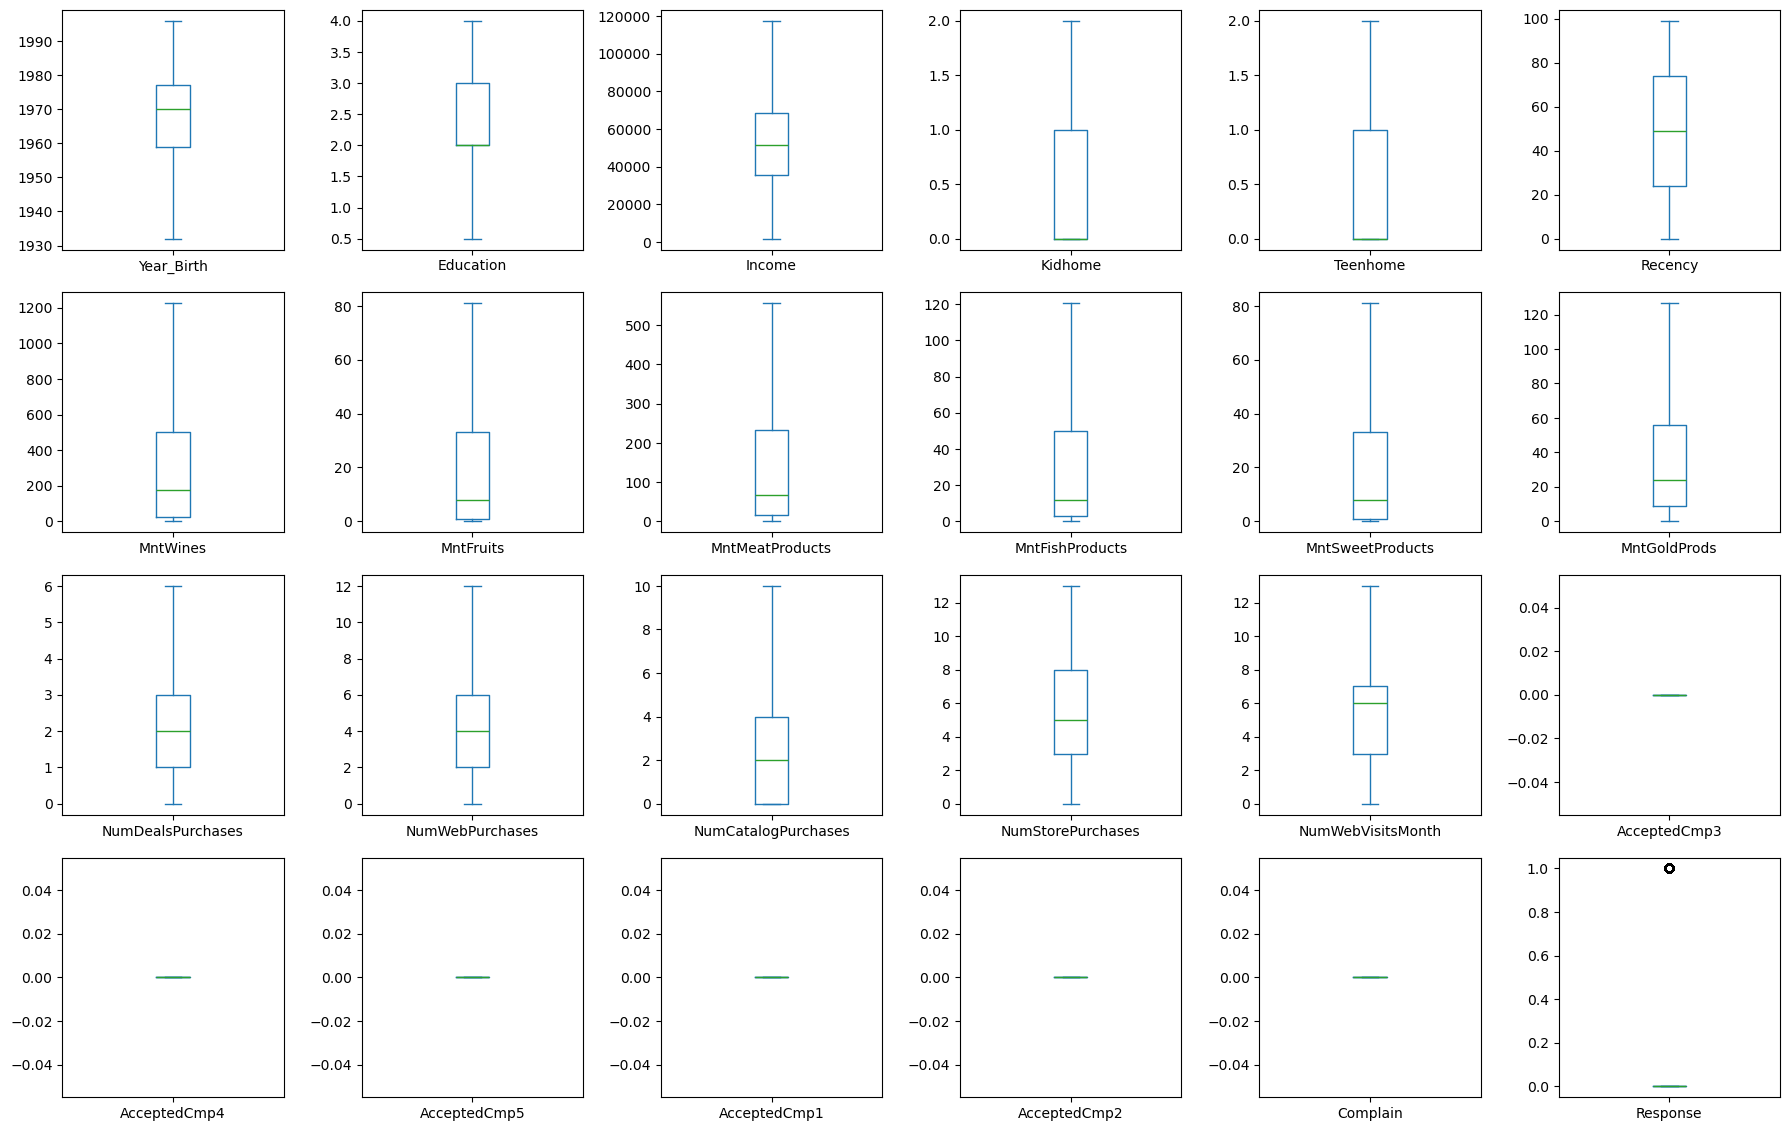

In [61]:
df.plot(kind='box', subplots=True, layout=(5,6), figsize=(18, 14))
plt.tight_layout()
plt.show()

### Part 2: Logistic Regression
#### Split  data into features and target

In [62]:
X = df.drop(columns=['Response'])
y = df['Response']

print(X.shape)
print(y.shape)

(2240, 27)
(2240,)


#### Scale the features and perform train/test split

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1792, 27)
(448, 27)


#### Train the logistic regression model

In [64]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
log_model.fit(X_train, y_train)

print("Model trained.")

Model trained.


#### Evaluate the model

In [72]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_log))
print(f"AUC: {roc_auc_score(y_test, y_prob_log):.4f}")
#print accuracy overall
print("Accuracy:",accuracy_score(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.96      0.76      0.85       381
           1       0.37      0.82      0.51        67

    accuracy                           0.77       448
   macro avg       0.67      0.79      0.68       448
weighted avg       0.87      0.77      0.80       448

AUC: 0.8740
Accuracy: 0.765625


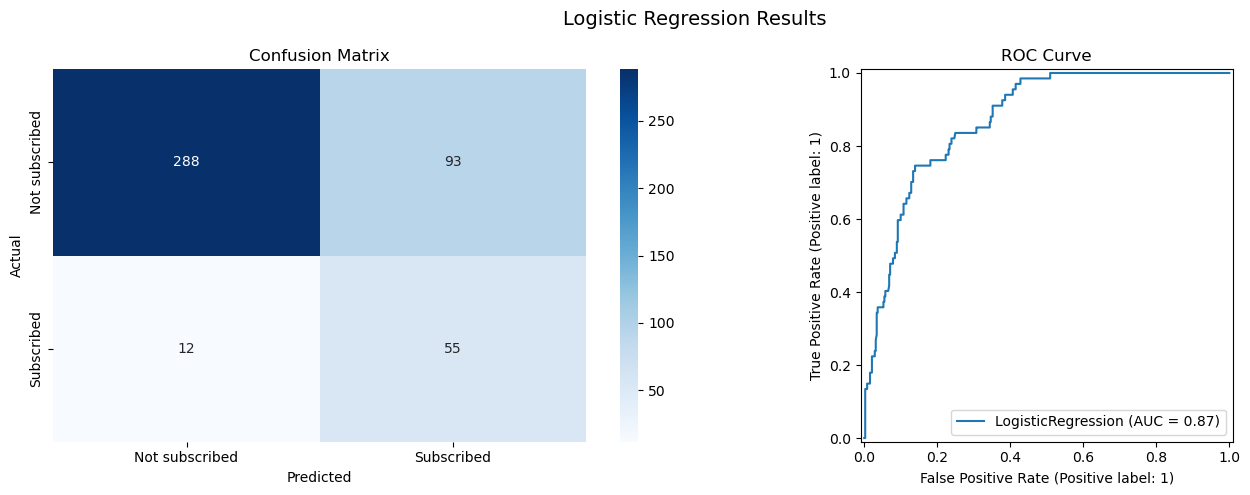

In [66]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not subscribed', 'Subscribed'],
            yticklabels=['Not subscribed', 'Subscribed'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC curve
RocCurveDisplay.from_estimator(log_model, X_test, y_test, ax=axes[1])
axes[1].set_title('ROC Curve')

plt.suptitle('Logistic Regression Results', fontsize=14)
plt.tight_layout()
plt.show()

#### Feature importance

In [77]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df.head(10))

                    Feature  Coefficient
16        NumWebVisitsMonth     0.873508
15        NumStorePurchases    -0.800424
5                   Recency    -0.750897
4                  Teenhome    -0.722983
14      NumCatalogPurchases     0.619577
25  Marital_Status_Together    -0.499218
23   Marital_Status_Married    -0.468133
6                  MntWines     0.462372
2                    Income     0.412011
8           MntMeatProducts     0.357276


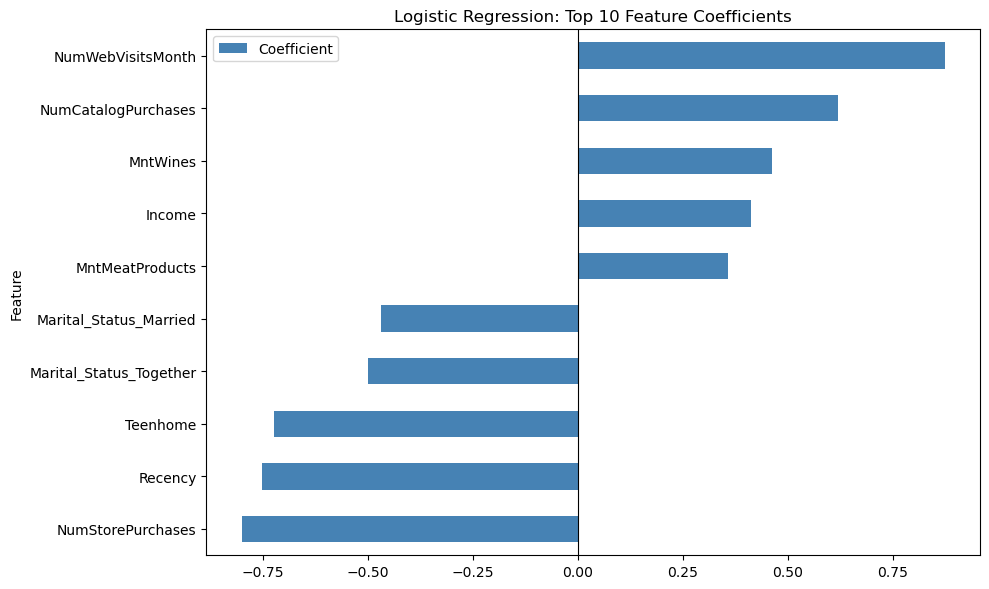

In [78]:
coef_df.head(10).sort_values('Coefficient').plot(
    kind='barh', x='Feature', y='Coefficient',
    figsize=(10, 6), color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression: Top 10 Feature Coefficients')
plt.tight_layout()
plt.show()

### Part 3: SVM Model
#### Train the SVM model

In [79]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm_model.fit(X_train, y_train)

print("SVM model trained.")

SVM model trained.


#### Evaluate the SVM model

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_svm))
print(f"AUC: {roc_auc_score(y_test, y_prob_svm):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}") 

              precision    recall  f1-score   support

           0       0.95      0.82      0.88       381
           1       0.42      0.75      0.53        67

    accuracy                           0.81       448
   macro avg       0.68      0.78      0.71       448
weighted avg       0.87      0.81      0.83       448

AUC: 0.8762
Accuracy: 0.8058


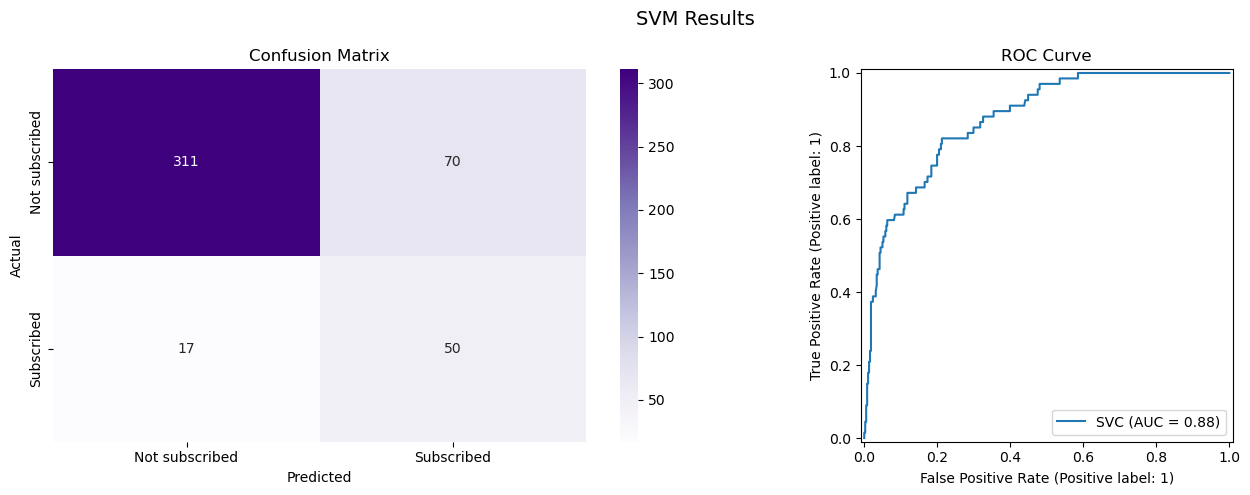

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not subscribed', 'Subscribed'],
            yticklabels=['Not subscribed', 'Subscribed'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC curve
RocCurveDisplay.from_estimator(svm_model, X_test, y_test, ax=axes[1])
axes[1].set_title('ROC Curve')

plt.suptitle('SVM Results', fontsize=14)
plt.tight_layout()
plt.show()

#### SVM feature importance

In [84]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    svm_model, X_test, y_test,
    n_repeats=10, random_state=42, scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=False)

print(perm_df.head(10))

                Feature  Importance
5               Recency    0.090708
14  NumCatalogPurchases    0.077628
16    NumWebVisitsMonth    0.046756
15    NumStorePurchases    0.044939
4              Teenhome    0.037617
8       MntMeatProducts    0.031371
2                Income    0.026744
11         MntGoldProds    0.024770
12    NumDealsPurchases    0.022509
6              MntWines    0.021346


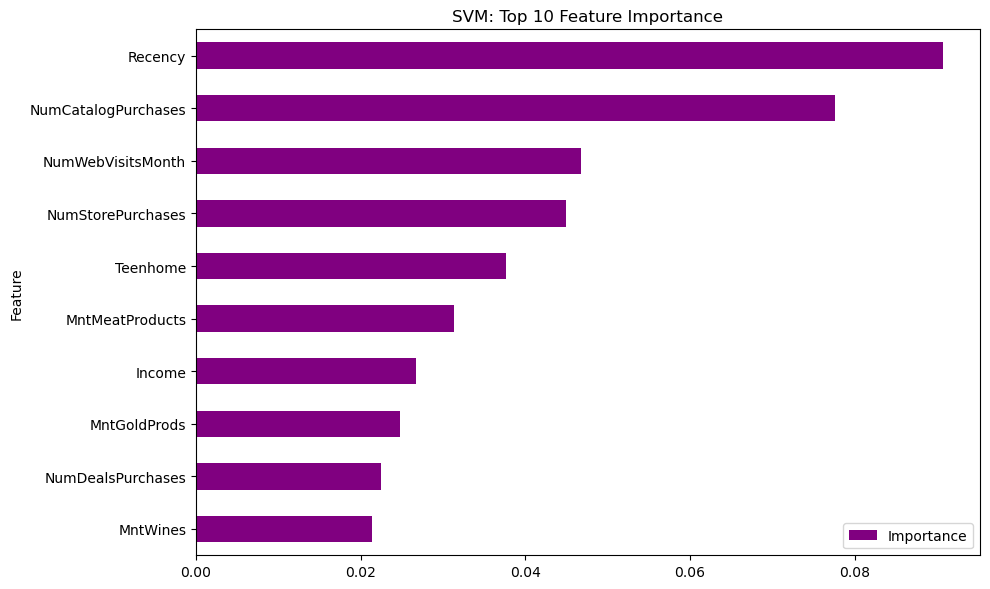

In [85]:
perm_df.head(10).sort_values('Importance').plot(
    kind='barh', x='Feature', y='Importance',
    figsize=(10, 6), color='purple')
plt.title('SVM: Top 10 Feature Importance')
plt.tight_layout()
plt.show()

### Part 4: Model Comparison
#### Build the comparison table

In [88]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'AUC', 'Precision (class 1)', 'Recall (class 1)', 'F1 Score (class 1)'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_log),
        roc_auc_score(y_test, y_prob_log),
        precision_score(y_test, y_pred_log, pos_label=1),
        recall_score(y_test, y_pred_log, pos_label=1),
        f1_score(y_test, y_pred_log, pos_label=1)
    ],
    'SVM': [
        accuracy_score(y_test, y_pred_svm),
        roc_auc_score(y_test, y_prob_svm),
        precision_score(y_test, y_pred_svm, pos_label=1),
        recall_score(y_test, y_pred_svm, pos_label=1),
        f1_score(y_test, y_pred_svm, pos_label=1)
    ]
}).round(4)

print(comparison.to_string(index=False))

             Metric  Logistic Regression    SVM
           Accuracy               0.7656 0.8058
                AUC               0.8740 0.8762
Precision (class 1)               0.3716 0.4167
   Recall (class 1)               0.8209 0.7463
 F1 Score (class 1)               0.5116 0.5348


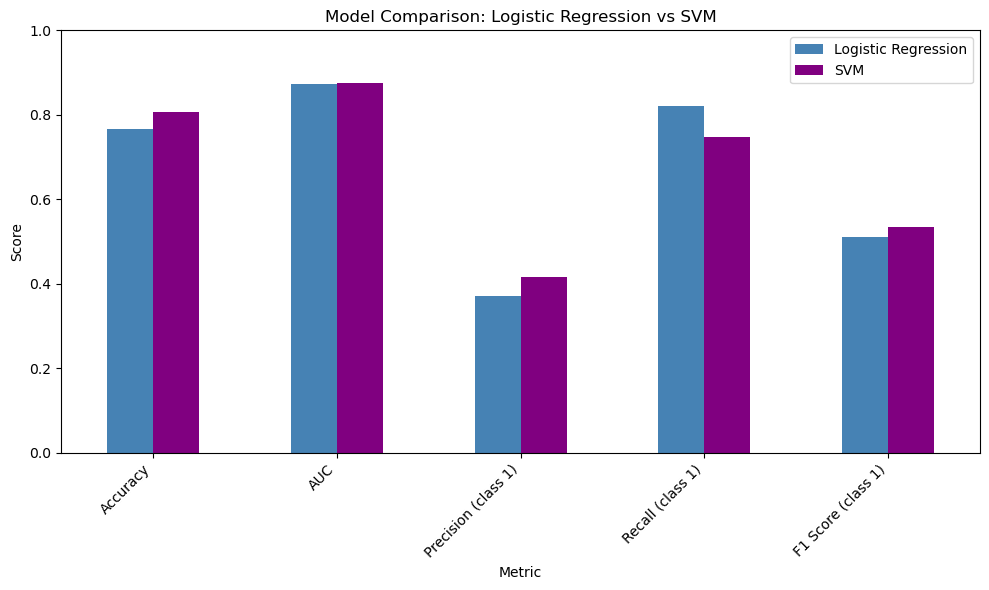

In [89]:
comparison.set_index('Metric').plot(
    kind='bar', figsize=(10, 6), color=['steelblue', 'purple'])
plt.title('Model Comparison: Logistic Regression vs SVM')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()